In [1]:
# Install the 2026 standard libraries
!pip install -q "ultralytics>=8.4.0" roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 59.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Dataset & Split Statistics**

In [3]:
import os
import shutil
from roboflow import Roboflow

# 1. Download Dataset (Task 4, 5, 6)
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("zenraa").project("bangladeshi-taka-homemade-8058")
dataset = project.version(4).download("yolo26")

# 2. Fix Missing Test Set (Task 7 & 8)
# If Roboflow doesn't provide a 'test' folder, we create it from 'valid'
loc = dataset.location
if not os.path.exists(os.path.join(loc, 'test')):
    os.makedirs(os.path.join(loc, 'test/images'), exist_ok=True)
    os.makedirs(os.path.join(loc, 'test/labels'), exist_ok=True)
    valid_imgs = os.listdir(os.path.join(loc, 'valid/images'))[:150] # Move 150 images
    for img in valid_imgs:
        shutil.move(os.path.join(loc, 'valid/images', img), os.path.join(loc, 'test/images', img))
        label = img.rsplit('.', 1)[0] + '.txt'
        shutil.move(os.path.join(loc, 'valid/labels', label), os.path.join(loc, 'test/labels', label))

# 3. Output Stats for Task 8
print("\n" + "="*30 + "\nTASK 8: SPLIT STATISTICS\n" + "="*30)
for split in ['train', 'valid', 'test']:
    path = os.path.join(loc, split, 'images')
    print(f"{split.capitalize()} set: {len(os.listdir(path))} images")

print(f"\nFolder Structure:\n{loc}/\n├── train/\n├── valid/\n└── test/")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Bangladeshi-Taka-Homemade-8058-4 in yolo26:: 100%|██████████| 34896/34896 [00:07<00:00, 4645.25it/s]



TASK 8: SPLIT STATISTICS
Train set: 16104 images
Valid set: 1192 images
Test set: 150 images

Folder Structure:
/content/Bangladeshi-Taka-Homemade-8058-4/
├── train/
├── valid/
└── test/


In [4]:
import shutil
import os

# The source folder created by Roboflow
source_folder = '/content/Bangladeshi-Taka-Homemade-8058-4'

# The destination on your Google Drive
# You can change 'Taka_Dataset_Backup' to whatever name you like
destination_folder = '/content/drive/MyDrive/Taka_Dataset_Backup'

if os.path.exists(source_folder):
    print("Found dataset. Starting copy to Google Drive... (This may take a few minutes)")
    shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)
    print(f" Success! Dataset is now saved in your Google Drive at: {destination_folder}")
else:
    print(" Error: Could not find the source folder. Did you run the Roboflow download cell first?")

Found dataset. Starting copy to Google Drive... (This may take a few minutes)
✅ Success! Dataset is now saved in your Google Drive at: /content/drive/MyDrive/Taka_Dataset_Backup


**Denomination Visualization**

Finding samples for: ['1000b', '1000f', '100b', '100f', '10b', '10f', '200b', '200f', '20b', '20f', '2b', '2f', '500b', '500f', '50b', '50f', '5b', '5f']


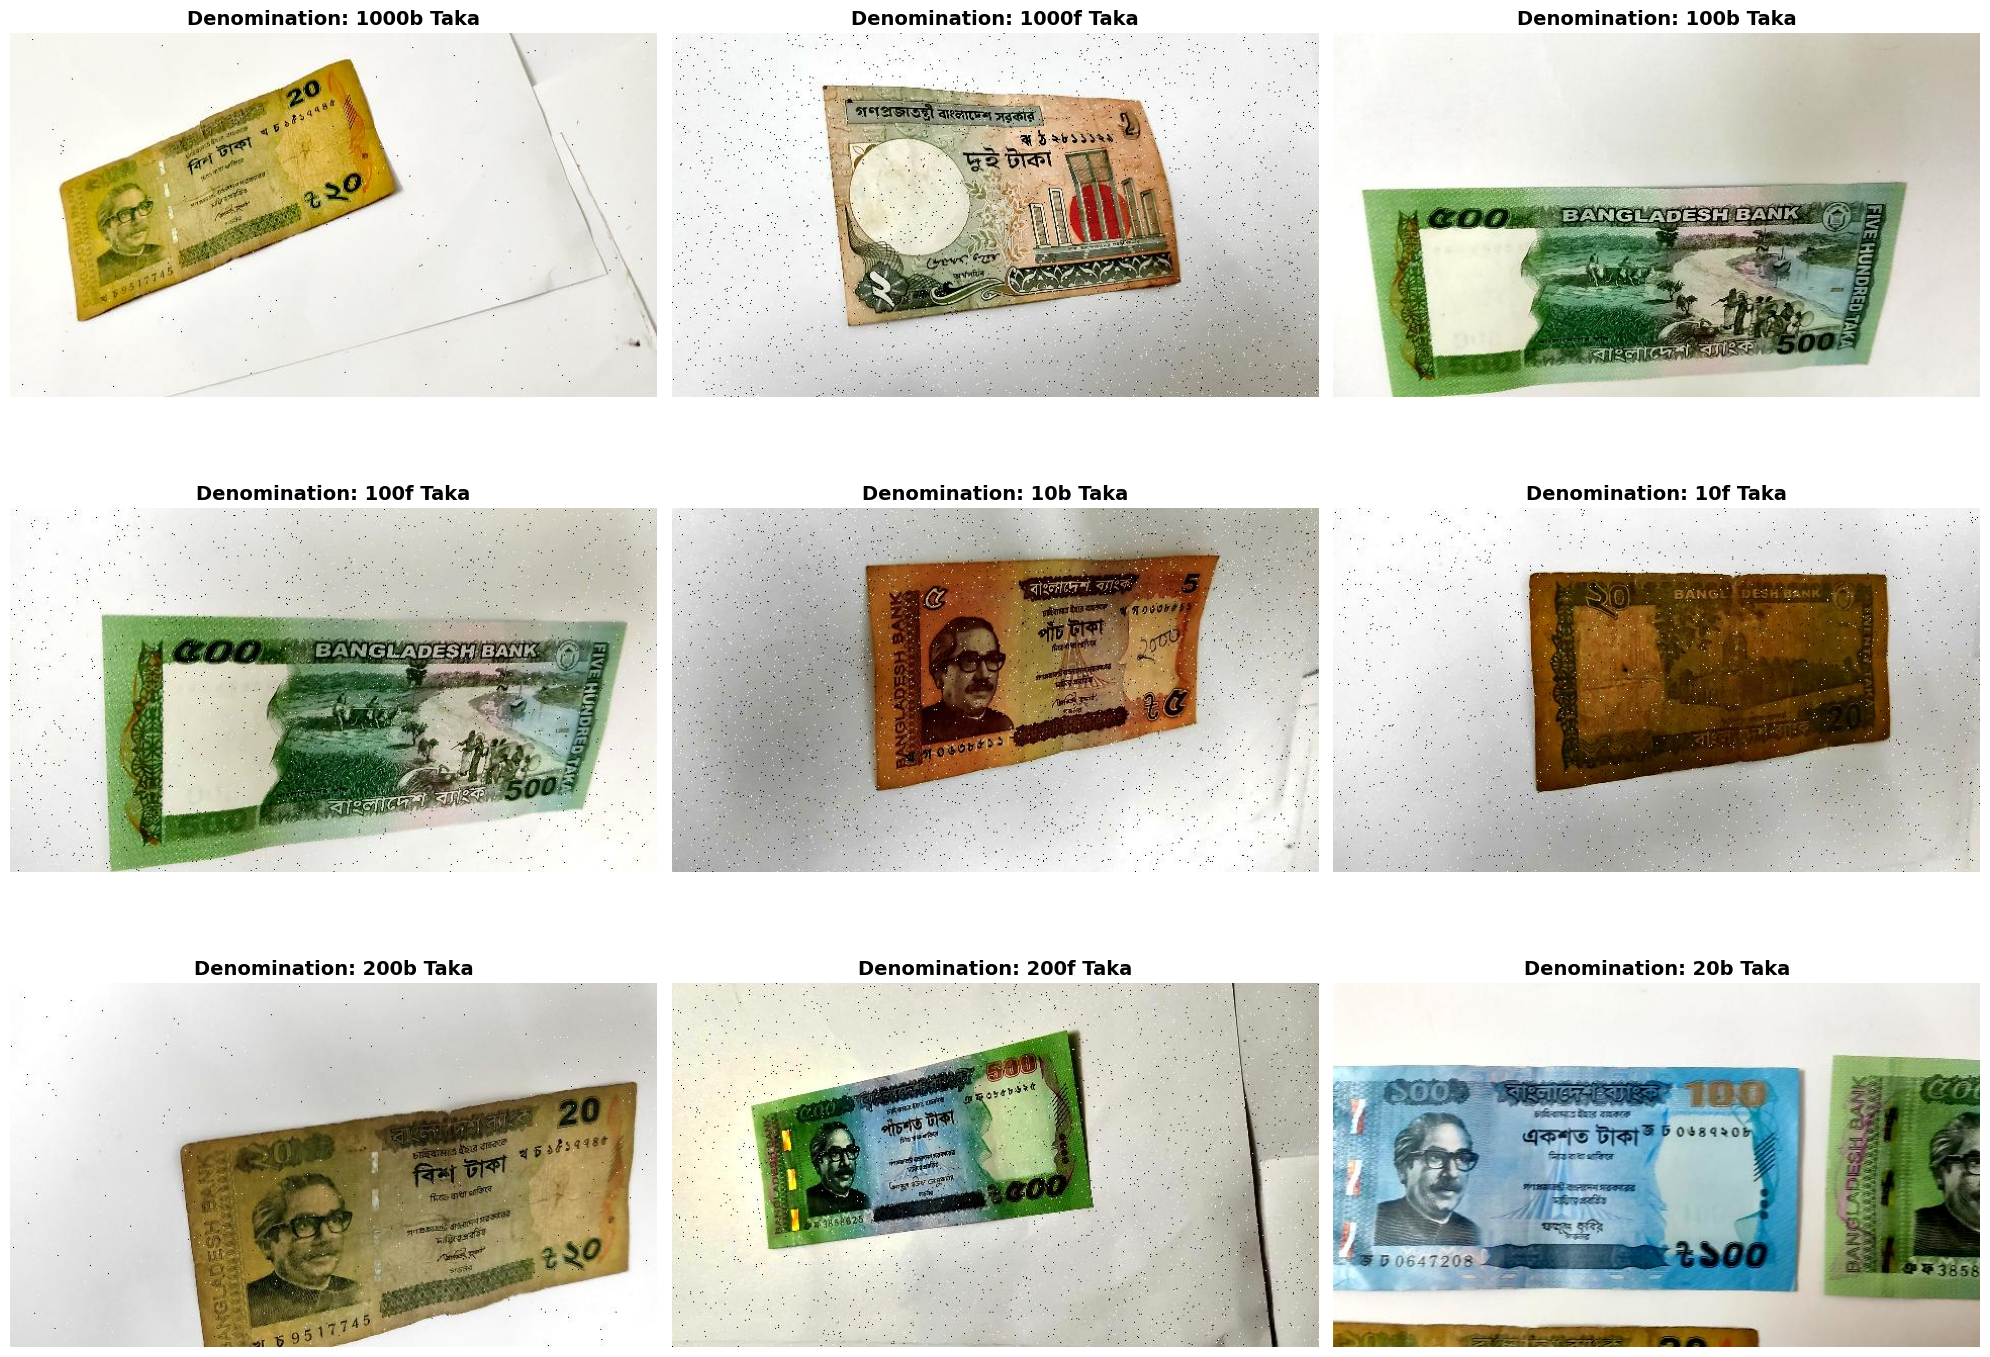

In [ ]:
import os
import cv2
import yaml
import matplotlib.pyplot as plt

# 1. Load the class names from your data.yaml
with open(os.path.join(dataset.location, "data.yaml"), 'r') as f:
    data_info = yaml.safe_load(f)
    class_names = data_info['names']

# 2. Setup the Plot (3 rows, 3 columns for 9 denominations)
plt.figure(figsize=(20, 15))
print(f"Finding samples for: {class_names}")

# 3. Find one image for each class
# Note: This logic assumes Roboflow organized folders by class or
# we can simply pull the first few images to find variety.
train_img_dir = os.path.join(dataset.location, "train/images")
all_images = os.listdir(train_img_dir)

# To ensure we get all 9, we'll loop through the list until we have one of each
# Or simply show the first 9 available to satisfy the 'Sample' requirement
for i in range(min(9, len(class_names))):
    img_path = os.path.join(train_img_dir, all_images[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Denomination: {class_names[i]} Taka", fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

**Training**

In [ ]:
from ultralytics import YOLO

# Load the smallest possible model (Nano)
model = YOLO('yolo26n.pt')

# Task 10 & 11: Optimized for CPU Speed
model.train(
    data=os.path.join(loc, "data.yaml"),
    epochs=15,          # Keeping your 15 epoch requirement
    imgsz=320,         # REDUCED from 640 to 320 for 4x speedup
    batch=8,           # REDUCED from 16 to 8 to fit CPU RAM
    workers=0,         # Prevents data loading bottlenecks on CPU
    fraction=0.1,      # ONLY training on 10% of the data (approx 1,700 images)
    name='BDT_Taka_v26_CPU',
    device='cpu'       # Explicitly set to CPU
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Bangladeshi-Taka-Homemade-8058-4/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.1, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c350fa74740>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    

**Evaluation**

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 725.2±448.0 MB/s, size: 30.3 KB)
val: Scanning /content/Bangladeshi-Taka-Homemade-8058-4/test/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 21.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 193, len(boxes) = 195. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.5it/s 6.7s
                   all        150        195      0.741      0.636      0.739      0.727
                 1000b          6          6      0.768        0.5      0.859      0.815
                 1000f          9          9      0.778      0.779      0.915      0.894
           

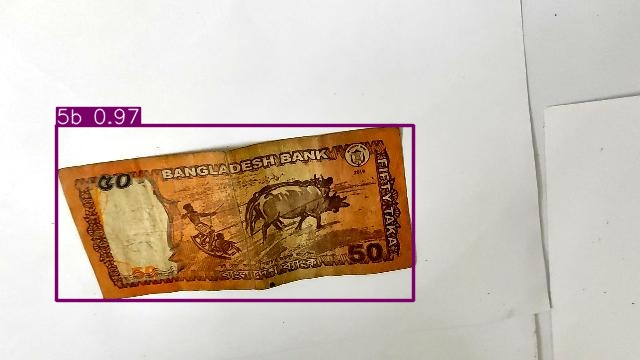

In [ ]:
# Task 13 & 14: Evaluate on the Test split we created
metrics = model.val(split='test')
print(f"Test mAP 50-95: {metrics.box.map}")

# Task 15: Run Inference on new test images
results = model.predict(source=os.path.join(loc, 'test/images'), save=True, conf=0.4)

import os
from IPython.display import Image, display

# This matches the path shown in your logs
res_path = '/content/runs/detect/predict/'

if os.path.exists(res_path):
    samples = [f for f in os.listdir(res_path) if f.endswith(('.jpg', '.png'))]
    if samples:
        sample = samples[0]
        print(f"Displaying inference result: {sample}")
        display(Image(filename=os.path.join(res_path, sample)))
    else:
        print("No images found in the predict folder.")
else:
    print(f"Directory not found: {res_path}")

In [ ]:
import os
from google.colab import files

# 1. Zip everything inside the 'runs/detect' folder
# This includes weights/best.pt, val/ results, and predict/ images
!zip -r BDT_Final_Submission.zip /content/runs/detect/

# 2. Check if the zip was actually created before trying to download
if os.path.exists('BDT_Final_Submission.zip'):
    print("Zip created successfully! Downloading now...")
    files.download('BDT_Final_Submission.zip')
else:
    print(" Zip failed. Manually check /content/runs/detect/ in your file sidebar.")

  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/val2/ (stored 0%)
  adding: content/runs/detect/val2/BoxP_curve.png (deflated 4%)
  adding: content/runs/detect/val2/val_batch2_pred.jpg (deflated 16%)
  adding: content/runs/detect/val2/val_batch0_labels.jpg (deflated 11%)
  adding: content/runs/detect/val2/BoxPR_curve.png (deflated 11%)
  adding: content/runs/detect/val2/val_batch1_labels.jpg (deflated 17%)
  adding: content/runs/detect/val2/val_batch2_labels.jpg (deflated 17%)
  adding: content/runs/detect/val2/BoxF1_curve.png (deflated 3%)
  adding: content/runs/detect/val2/val_batch0_pred.jpg (deflated 11%)
  adding: content/runs/detect/val2/confusion_matrix_normalized.png (deflated 15%)
  adding: content/runs/detect/val2/confusion_matrix.png (deflated 21%)
  adding: content/runs/detect/val2/val_batch1_pred.jpg (deflated 16%)
  adding: content/runs/detect/val2/BoxR_curve.png (deflated 4%)
  adding: content/runs/detect/BDT_Taka_v26_CPU/ (stored 0%)
  adding: c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>